# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

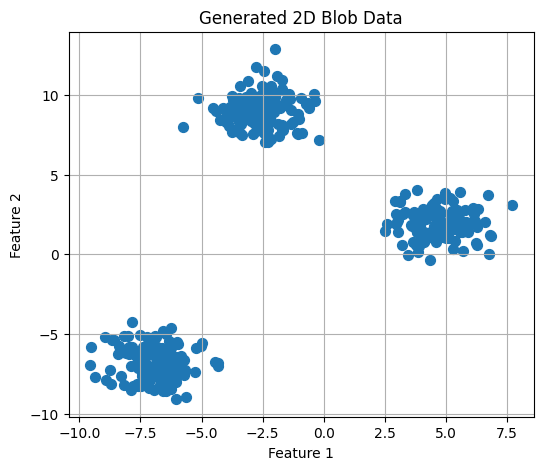

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


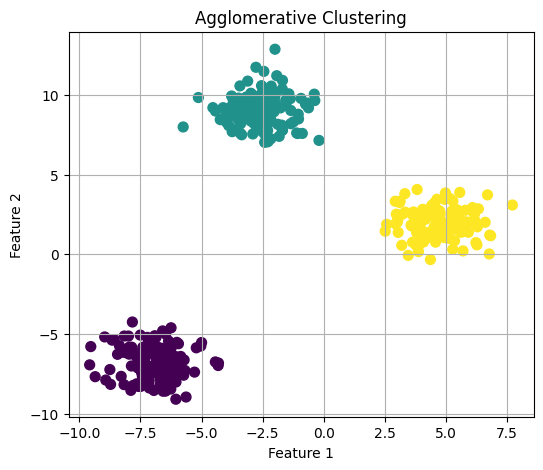

In [2]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

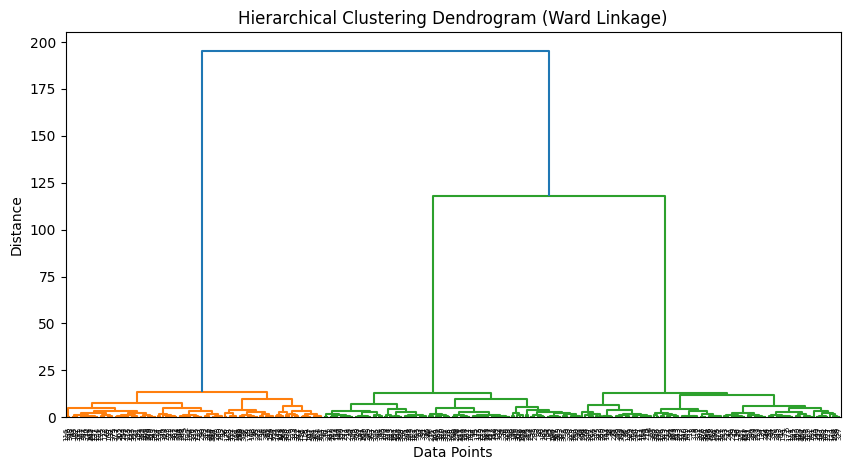

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv('CC-GENERAL.csv', sep=',')
df = df.copy()

In [7]:
df.info()

# Separating numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [8]:
# Check distribution & skew of numeric columns
for col in numeric_cols:
    print(f"Distribution of {col}:")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew()}")
    print("\n")

Distribution of BALANCE:
count     8950.000000
mean      1564.474828
std       2081.531879
min          0.000000
25%        128.281915
50%        873.385231
75%       2054.140036
max      19043.138560
Name: BALANCE, dtype: float64
Skewness: 2.393386042571806


Distribution of BALANCE_FREQUENCY:
count    8950.000000
mean        0.877271
std         0.236904
min         0.000000
25%         0.888889
50%         1.000000
75%         1.000000
max         1.000000
Name: BALANCE_FREQUENCY, dtype: float64
Skewness: -2.0232655185149078


Distribution of PURCHASES:
count     8950.000000
mean      1003.204834
std       2136.634782
min          0.000000
25%         39.635000
50%        361.280000
75%       1110.130000
max      49039.570000
Name: PURCHASES, dtype: float64
Skewness: 8.144269064554651


Distribution of ONEOFF_PURCHASES:
count     8950.000000
mean       592.437371
std       1659.887917
min          0.000000
25%          0.000000
50%         38.000000
75%        577.405000
max      40

In [9]:
# Ckeck counts of categorical columns
for col in categorical_cols:
    print(f"Value counts of {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts of CUST_ID:
CUST_ID
C19190    1
C10001    1
C10002    1
C10003    1
C10004    1
         ..
C10011    1
C10010    1
C10009    1
C10008    1
C10007    1
Name: count, Length: 8950, dtype: int64




In [10]:
# Identify missing or unknown values and handle them appropriately
for col in df.columns:
    missing_count = df[col].isnull().sum()
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col}: Missing={missing_count}, Unknown={unknown_count}")
df.replace("unknown", pd.NA, inplace=True)
df[categorical_cols] = df[categorical_cols].fillna("Missing")
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

CUST_ID: Missing=0, Unknown=0
BALANCE: Missing=0, Unknown=0
BALANCE_FREQUENCY: Missing=0, Unknown=0
PURCHASES: Missing=0, Unknown=0
ONEOFF_PURCHASES: Missing=0, Unknown=0
INSTALLMENTS_PURCHASES: Missing=0, Unknown=0
CASH_ADVANCE: Missing=0, Unknown=0
PURCHASES_FREQUENCY: Missing=0, Unknown=0
ONEOFF_PURCHASES_FREQUENCY: Missing=0, Unknown=0
PURCHASES_INSTALLMENTS_FREQUENCY: Missing=0, Unknown=0
CASH_ADVANCE_FREQUENCY: Missing=0, Unknown=0
CASH_ADVANCE_TRX: Missing=0, Unknown=0
PURCHASES_TRX: Missing=0, Unknown=0
CREDIT_LIMIT: Missing=1, Unknown=0
PAYMENTS: Missing=0, Unknown=0
MINIMUM_PAYMENTS: Missing=313, Unknown=0
PRC_FULL_PAYMENT: Missing=0, Unknown=0
TENURE: Missing=0, Unknown=0


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nouna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Correlation Matrix:
                                   BALANCE  BALANCE_FREQUENCY  PURCHASES  \
BALANCE                           1.000000           0.322412   0.181261   
BALANCE_FREQUENCY                 0.322412           1.000000   0.133674   
PURCHASES                         0.181261           0.133674   1.000000   
ONEOFF_PURCHASES                  0.164350           0.104323   0.916845   
INSTALLMENTS_PURCHASES            0.126469           0.124292   0.679896   
CASH_ADVANCE                      0.496692           0.099388  -0.051474   
PURCHASES_FREQUENCY              -0.077944           0.229715   0.393017   
ONEOFF_PURCHASES_FREQUENCY        0.073166           0.202415   0.498430   
PURCHASES_INSTALLMENTS_FREQUENCY -0.063186           0.176079   0.315567   
CASH_ADVANCE_FREQUENCY            0.449218           0.191873  -0.120143   
CASH_ADVANCE_TRX                  0.385152           0.141555  -0.067175   
PURCHASES_TRX                     0.154338           0.189626   0.68

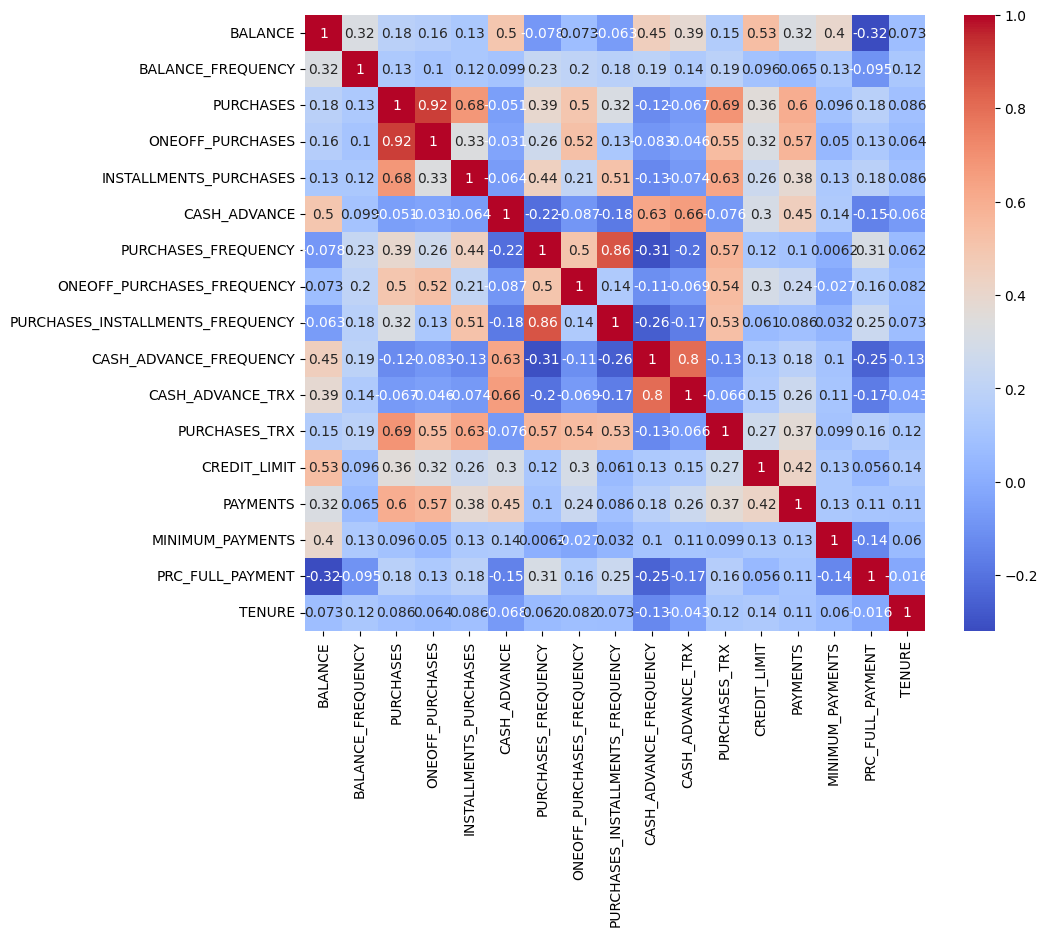

In [11]:
%pip install seaborn
        
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()


In [12]:
# Identify outliers in numeric columns using iQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers[[col]])
    print("\n")

Outliers in BALANCE:
           BALANCE
15     6886.213231
21     6369.531318
24     5368.571219
28     7152.864372
30    12136.219960
...            ...
8309   6008.914524
8411   5934.610587
8438   5484.339435
8705   7302.672686
8941   5967.475270

[695 rows x 1 columns]


Outliers in BALANCE_FREQUENCY:
      BALANCE_FREQUENCY
3              0.636364
9              0.545455
17             0.454545
22             0.636364
39             0.454545
...                 ...
8929           0.333333
8937           0.666667
8938           0.500000
8943           0.500000
8949           0.666667

[1493 rows x 1 columns]


Outliers in PURCHASES:
      PURCHASES
6       7091.01
12      3217.99
21      6359.95
23      4248.35
30      3038.01
...         ...
8689    8053.95
8737    5633.83
8748    3950.00
8758    2918.08
8897    2806.78

[808 rows x 1 columns]


Outliers in ONEOFF_PURCHASES:
      ONEOFF_PURCHASES
3              1499.00
6              6402.63
11             1492.18
12             2

## **2. Data Preparation**

In [13]:
# Drop target or irrelevant columns
df.drop('CUST_ID', axis=1, inplace=True)
categorical_cols = categorical_cols.drop('CUST_ID')

In [ ]:
# No Categorical columns to encode, since CUST_ID was the only one and we dropped it.

In [15]:
# Scale numeric features so all are comparable
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [16]:
# Check that the final data has no missing values & all features are numeric
print("Final Data Info:")
print(df.info())

Final Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   float64
 11  PURCHASES_TRX                     8950 non-null   fl

## **3. Apply Agglomerative Clustering**

In [26]:
agg = AgglomerativeClustering(
    n_clusters=2,     
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)


In [27]:
# Fit and predict cluster labels on the prepared credit‑card dataset
labels = agg.fit_predict(df)        


In [28]:
# Assign each data point to its respective cluster
df['Cluster'] = labels

## **4. Visualize the Clustering Results**

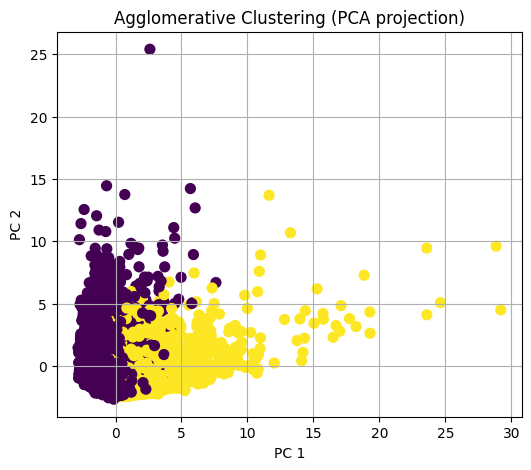

In [29]:
# reduce to 2‑D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Agglomerative Clustering (PCA projection)")
plt.grid(True)
plt.show()

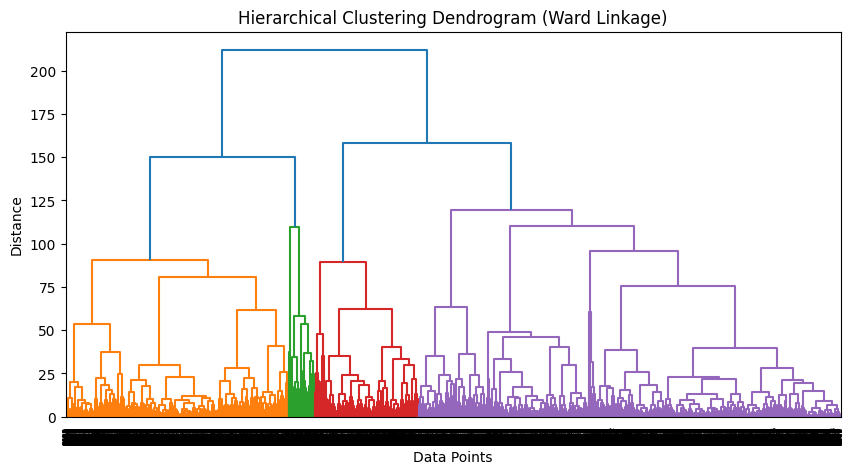

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(df, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## **5. Evaluate the Clustering**

In [31]:
# Compute silhouette scores for different numbers of clusters
cluster_range = range(2, 9)
sil_scores = []

for k in cluster_range:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )
    labels = model.fit_predict(df.drop('Cluster', axis=1))
    sil = silhouette_score(df.drop('Cluster', axis=1), labels)
    sil_scores.append(sil)


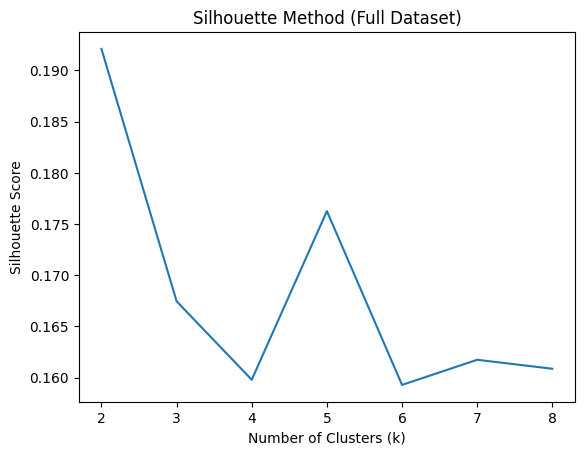


Optimal number of clusters: 2
Best silhouette score: 0.19210277656035374


In [32]:
plt.figure()
plt.plot(cluster_range, sil_scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (Full Dataset)")
plt.show()
best_k = cluster_range[np.argmax(sil_scores)]
print("\nOptimal number of clusters:", best_k)
print("Best silhouette score:", max(sil_scores))

## **6. Explain whether the clustering quality and justify your reasoning**

Based on the silhouette score of approximately 0.20, the clustering quality may be considered weak since the score indicates that the clusters are not strongly seperated and that there can be a noticeable overlap between clusters. However, the positive score indicates that there is some structure in the data.